In [59]:
# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Modeling, tuning, and evaluation
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor


### XGBoost Hyperparameter Optimization

After selecting the feature set, **Optuna** is used to optimize the XGBoost hyperparameters.

Each Optuna trial trains and evaluates an XGBoost model using **5-fold time-series cross-validation**, and the mean validation error across the five folds is used as the optimization objective.

The best-performing hyperparameter configuration is then used to train the final model. The held-out test set is only used for the final evaluation and is not involved in either feature selection or hyperparameter optimization.

In [53]:
df_selected = pd.read_csv(
    "data/training/selected_features.csv",
    index_col="datetime",
    parse_dates=["datetime"],
)
print(df_selected.head())
print(df_selected.info())
print(df_selected.shape)

                           t2m        d2m       u10       v10  ssrd  \
datetime                                                              
2018-03-02 00:00:00  266.69897  263.39282 -2.899322 -2.517242   0.0   
2018-03-02 01:00:00  266.90857  263.39297 -2.992996 -2.600937   0.0   
2018-03-02 02:00:00  267.09784  263.54614 -3.089279 -2.553818   0.0   
2018-03-02 03:00:00  267.33673  263.71246 -3.414139 -2.331518   0.0   
2018-03-02 04:00:00  267.49707  263.83014 -3.589371 -2.193220   0.0   

                               tp  snowc  day  weekday  month  hour_sin  \
datetime                                                                  
2018-03-02 00:00:00  9.685755e-07  100.0    2        4      3  0.000000   
2018-03-02 01:00:00  3.520399e-07  100.0    2        4      3  0.258819   
2018-03-02 02:00:00  4.526228e-07  100.0    2        4      3  0.500000   
2018-03-02 03:00:00  9.052455e-07  100.0    2        4      3  0.707107   
2018-03-02 04:00:00  1.177192e-06  100.0    2       

In [54]:
# 80% development / 20% final test split

X = df_selected.drop(columns=["total_consumption"])
y = df_selected["total_consumption"]

split_idx = int(len(df_selected) * 0.8)

df_dev = df_selected.iloc[:split_idx].copy()
df_test = df_selected.iloc[split_idx:].copy()

X_dev = df_dev.drop(columns=["total_consumption"])
y_dev = df_dev["total_consumption"]

X_test = df_test.drop(columns=["total_consumption"])
y_test = df_test["total_consumption"]

print("Development period:")
print(df_dev.index.min(), "→", df_dev.index.max())

print("\nTest period:")
print(df_test.index.min(), "→", df_test.index.max())

print(f"\nDevelopment observations: {len(df_dev):,}")
print(f"Test observations:        {len(df_test):,}")

Development period:
2018-03-02 00:00:00 → 2024-10-30 08:00:00

Test period:
2024-10-30 09:00:00 → 2026-06-30 23:00:00

Development observations: 58,425
Test observations:        14,607


In [55]:
# Optuna objective with 5-fold TimeSeriesSplit

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.3, log=True
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 10.0, log=True
        ),

        "random_state": 42,
        "n_jobs": -1
    }

    tscv = TimeSeriesSplit(n_splits=5)

    fold_maes = []

    for train_idx, val_idx in tscv.split(X_dev):

        X_train = X_dev.iloc[train_idx]
        X_val = X_dev.iloc[val_idx]

        y_train = y_dev.iloc[train_idx]
        y_val = y_dev.iloc[val_idx]

        model = XGBRegressor(**params)

        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred)
        fold_maes.append(mae)

    return np.mean(fold_maes)

In [56]:
# Run Optuna

study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=100
)

print("\nBest CV MAE:")
print(f"{study.best_value:.2f}")

print("\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")

[I 2026-09-24 11:10:40,024] A new study created in memory with name: no-name-885dd8d8-443c-4624-88cd-a5a802c2ceac
[I 2026-09-24 11:11:01,970] Trial 0 finished with value: 248.9263622031423 and parameters: {'n_estimators': 385, 'max_depth': 10, 'learning_rate': 0.05556838635320532, 'subsample': 0.9018472779617449, 'colsample_bytree': 0.6032164750806979, 'min_child_weight': 1, 'reg_alpha': 0.02343184843052417, 'reg_lambda': 2.094773297916497}. Best is trial 0 with value: 248.9263622031423.
[I 2026-09-24 11:11:20,866] Trial 1 finished with value: 257.6578971076291 and parameters: {'n_estimators': 482, 'max_depth': 10, 'learning_rate': 0.2012224035783023, 'subsample': 0.9222048098650075, 'colsample_bytree': 0.6322292076797332, 'min_child_weight': 10, 'reg_alpha': 1.4647269746536646e-06, 'reg_lambda': 2.0409666176124103e-06}. Best is trial 0 with value: 248.9263622031423.
[I 2026-09-24 11:11:51,798] Trial 2 finished with value: 243.8139189244598 and parameters: {'n_estimators': 721, 'max_de


Best CV MAE:
227.90

Best hyperparameters:
n_estimators: 872
max_depth: 6
learning_rate: 0.02313958212740941
subsample: 0.6262908803526831
colsample_bytree: 0.6422066379327717
min_child_weight: 7
reg_alpha: 1.9945967598062505e-05
reg_lambda: 0.0011660173332955633


In [57]:
# Train final model on ALL development data

best_params = study.best_params.copy()

final_model = XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_dev,
    y_dev
)


# Final evaluation on untouched 20% test set

y_pred = final_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print(f"MAE:  {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R²:   {test_r2:.4f}")


FINAL TEST RESULTS
MAE:  208.39
RMSE: 281.15
R²:   0.9773


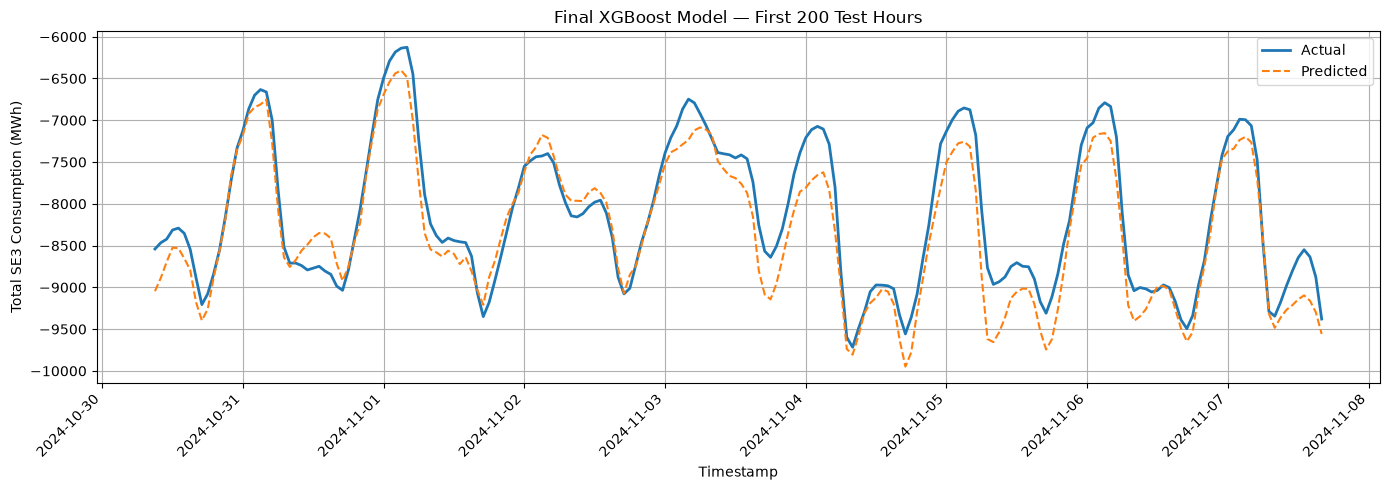

In [58]:
# index converting to datetime
plot_index = pd.to_datetime(y_test.index[:200])

plt.figure(figsize=(14, 5))

plt.plot(
    plot_index,
    y_test.iloc[:200],
    label="Actual",
    linewidth=2
)

plt.plot(
    plot_index,
    y_pred[:200],
    label="Predicted",
    linestyle="--"
)

plt.title("Final XGBoost Model — First 200 Test Hours")
plt.xlabel("Timestamp")
plt.ylabel("Total SE3 Consumption (MWh)")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

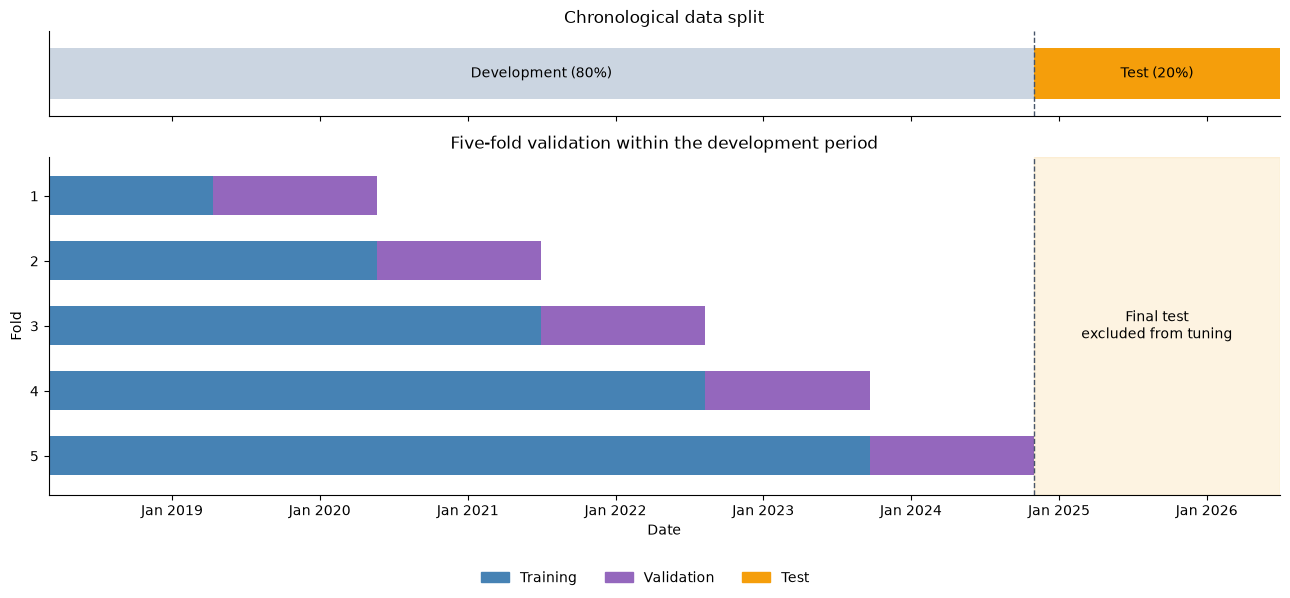

In [60]:
X_dev.index = pd.to_datetime(X_dev.index)
X_test.index = pd.to_datetime(X_test.index)

colors = {
    'development': '#CBD5E1',
    'training': '#4682B4',
    'validation': '#9467BD',
    'test': '#F59E0B',
}

dates = X_dev.index.append(X_test.index)
edges = mdates.date2num(
    dates.append(pd.DatetimeIndex([dates[-1] + pd.Timedelta(hours=1)]))
)

n_dev = len(X_dev)
start, boundary, end = edges[0], edges[n_dev], edges[-1]

def draw_bar(ax, first, stop, row, color):
    ax.broken_barh(
        [(edges[first], edges[stop] - edges[first])],
        (row - 0.3, 0.6),
        facecolors=color,
    )

tscv = TimeSeriesSplit(n_splits=5)

fig, (ax_top, ax_cv) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 4]},
)

draw_bar(ax_top, 0, n_dev, 0.5, colors['development'])
draw_bar(ax_top, n_dev, len(dates), 0.5, colors['test'])

ax_top.text(
    (start + boundary) / 2, 0.5, 'Development (80%)',
    ha='center', va='center',
)
ax_top.text(
    (boundary + end) / 2, 0.5, 'Test (20%)',
    ha='center', va='center',
)
ax_top.set(ylim=(0, 1), yticks=[], title='Chronological data split')

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_dev), start=1):
    draw_bar(
        ax_cv, train_idx[0], train_idx[-1] + 1,
        fold, colors['training'],
    )
    draw_bar(
        ax_cv, val_idx[0], val_idx[-1] + 1,
        fold, colors['validation'],
    )

ax_cv.axvspan(boundary, end, color=colors['test'], alpha=0.12)
ax_cv.text(
    (boundary + end) / 2, 3,
    'Final test\nexcluded from tuning',
    ha='center', va='center',
)

ax_cv.set(
    title='Five-fold validation within the development period',
    xlabel='Date',
    ylabel='Fold',
    yticks=range(1, 6),
    xlim=(start, end),
    ylim=(5.6, 0.4),
)

locator = mdates.AutoDateLocator(minticks=5, maxticks=9)
ax_cv.xaxis.set_major_locator(locator)
ax_cv.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

for ax in (ax_top, ax_cv):
    ax.axvline(boundary, color='#475569', linestyle='--', linewidth=1)
    ax.spines[['top', 'right']].set_visible(False)

fig.legend(
    handles=[
        Patch(color=colors['training'], label='Training'),
        Patch(color=colors['validation'], label='Validation'),
        Patch(color=colors['test'], label='Test'),
    ],
    loc='lower center', ncol=3, frameon=False,
)

plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

In [61]:
print(df_dev.index.min(), "→", df_dev.index.max())
print(df_test.index.min(), "→", df_test.index.max())

2018-03-02 00:00:00 → 2024-10-30 08:00:00
2024-10-30 09:00:00 → 2026-06-30 23:00:00
